# 🍽️ Zomato Restaurant Success Pattern Analysis
**Tools:** SQL (SQLite) · Python (Pandas, NumPy) · Matplotlib  
**Dataset:** [Zomato Bangalore Restaurants – Kaggle](https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants)

---
### Objective
What actually makes a restaurant go from 3.2★ to 4.5★ on Zomato?  
This project mines Zomato's open dataset to find the real drivers of restaurant success — cuisine, price point, location, or online services.


In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110
})
print("Libraries loaded ✅")


Libraries loaded ✅


## Step 1 — Load Dataset

In [3]:
df_raw = pd.read_csv("zomato.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(3)


Shape: (51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


## Step 2 — Data Cleaning (Pandas)
Fixing the `rate` column (comes as `"4.1/5"`), removing commas from cost, 
standardising location strings, parsing multi-cuisine tags, and engineering new features.


In [4]:
df = df_raw.copy()

# Fix rating — "4.1/5" → 4.1, "NEW"/"–" → NaN
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Fix approx cost — remove commas
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str).str.replace(',', '', regex=False)
)
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce'
)

# Rename for convenience
df.rename(columns={
    'approx_cost(for two people)': 'approx_cost',
    'listed_in(type)': 'listed_type',
    'listed_in(city)': 'listed_city'
}, inplace=True)

# Clean location strings
df['location'] = df['location'].astype(str).str.strip().str.title()

# Extract primary cuisine (first in list)
df['primary_cuisine'] = (
    df['cuisines'].astype(str)
    .str.split(',').str[0].str.strip().str.title()
)

# Binary flags
df['online_order_flag'] = (df['online_order'].astype(str).str.strip() == 'Yes').astype(int)
df['book_table_flag']   = (df['book_table'].astype(str).str.strip()   == 'Yes').astype(int)
df['both_services']     = ((df['online_order_flag'] == 1) & (df['book_table_flag'] == 1)).astype(int)

# Price tier
df['price_tier'] = pd.cut(
    df['approx_cost'],
    bins=[0, 300, 600, 1000, 10000],
    labels=['Budget', 'Mid-range', 'Premium', 'Luxury']
)

# Engagement quality metric
df['rating_per_vote'] = df['rate'] / (np.log1p(df['votes']) + 1)

# Drop missing essentials
df_clean = df.dropna(subset=['rate', 'votes', 'approx_cost']).copy()
df_clean = df_clean[df_clean['rate'] > 0]

print(f"After cleaning: {df_clean.shape[0]:,} rows")
df_clean[['name', 'location', 'rate', 'votes', 'approx_cost', 'primary_cuisine',
          'online_order_flag', 'book_table_flag', 'price_tier']].head()


After cleaning: 41,418 rows


,name,location,rate,votes,approx_cost,primary_cuisine,online_order_flag,book_table_flag,price_tier
0,Jalsa,Banashankari,4.1,775,800.0,North Indian,1,1,Premium
1,Spice Elephant,Banashankari,4.1,787,800.0,Chinese,1,0,Premium
2,San Churro Cafe,Banashankari,3.8,918,800.0,Cafe,1,0,Premium
3,Addhuri Udupi Bhojana,Banashankari,3.7,88,300.0,South Indian,0,0,Budget
4,Grand Village,Basavanagudi,3.8,166,600.0,North Indian,0,0,Mid-range


## Step 3 — SQL Analysis (SQLite)
Loading the cleaned dataframe into an in-memory SQLite database,  
then running queries with **CTEs** and **window functions**.


In [5]:
conn = sqlite3.connect(":memory:")
df_clean.to_sql("restaurants", conn, index=False, if_exists="replace")
print("Loaded into SQLite ✅  Rows:", pd.read_sql("SELECT COUNT(*) AS n FROM restaurants", conn).iloc[0,0])


Loaded into SQLite ✅  Rows: 41418


### Query 1 — Top cuisines by avg rating (CTE + window rank)

In [6]:
q1 = """
WITH cuisine_stats AS (
    SELECT
        primary_cuisine,
        COUNT(*)                    AS total_listings,
        ROUND(AVG(rate), 2)         AS avg_rating,
        ROUND(AVG(votes), 0)        AS avg_votes,
        ROUND(AVG(approx_cost), 0)  AS avg_cost
    FROM restaurants
    WHERE primary_cuisine IS NOT NULL
    GROUP BY primary_cuisine
    HAVING COUNT(*) >= 50
),
ranked AS (
    SELECT *,
           RANK() OVER (ORDER BY avg_rating DESC) AS rating_rank
    FROM cuisine_stats
)
SELECT * FROM ranked ORDER BY avg_rating DESC LIMIT 15
"""
cuisine_df = pd.read_sql(q1, conn)
cuisine_df


,primary_cuisine,total_listings,avg_rating,avg_votes,avg_cost,rating_rank
0,Modern Indian,109,4.31,1080.0,1585.0,1
1,European,229,4.26,1638.0,1790.0,2
2,Mediterranean,101,4.20,1356.0,1355.0,3
3,Japanese,112,4.19,918.0,1938.0,4
4,American,441,4.16,1906.0,1353.0,5
5,Asian,370,4.15,921.0,1328.0,6
6,Goan,77,4.04,429.0,977.0,7
7,Thai,128,4.04,668.0,1473.0,7
8,Lebanese,65,4.02,249.0,765.0,9
9,Bbq,108,4.00,452.0,898.0,10


### Query 2 — Online order + table booking impact

In [7]:
q2 = """
SELECT
    online_order,
    book_table,
    COUNT(*)             AS count,
    ROUND(AVG(rate), 2)  AS avg_rating,
    ROUND(AVG(votes), 0) AS avg_votes
FROM restaurants
GROUP BY online_order, book_table
ORDER BY avg_rating DESC
"""
service_df = pd.read_sql(q2, conn)
service_df


,online_order,book_table,count,avg_rating,avg_votes
0,No,Yes,2550,4.16,1167.0
1,Yes,Yes,3754,4.13,1174.0
2,Yes,No,23452,3.66,210.0
3,No,No,11662,3.55,193.0


### Query 3 — Top 3 restaurants by votes per city (window function)

In [8]:
q3 = """
SELECT * FROM (
    SELECT
        name, location, rate, votes,
        online_order, book_table,
        RANK() OVER (PARTITION BY location ORDER BY votes DESC) AS city_rank
    FROM restaurants
)
WHERE city_rank <= 3
ORDER BY location, city_rank
LIMIT 30
"""
top_df = pd.read_sql(q3, conn)
top_df.head(15)


,name,location,rate,votes,online_order,book_table,city_rank
0,Onesta,Banashankari,4.6,2604,Yes,Yes,1
1,Onesta,Banashankari,4.6,2556,Yes,Yes,2
2,Onesta,Banashankari,4.6,2556,Yes,Yes,2
3,Onesta,Banashankari,4.6,2556,Yes,Yes,2
4,Onesta,Banashankari,4.6,2556,Yes,Yes,2
5,Saffron Vegetarian Cuisine,Banaswadi,4.0,671,Yes,Yes,1
6,Saffron Vegetarian Cuisine,Banaswadi,4.0,667,Yes,Yes,2
7,Saffron Vegetarian Cuisine,Banaswadi,4.0,667,Yes,Yes,2
8,Saffron Vegetarian Cuisine,Banaswadi,4.0,667,Yes,Yes,2
9,Empire Restaurant,Bannerghatta Road,4.3,3178,Yes,No,1


## Step 4 — Correlation Analysis (NumPy)
Testing which variables (online ordering, table booking, cuisine type, avg cost) 
most strongly predict high ratings.


In [9]:
features = ['online_order_flag', 'book_table_flag', 'both_services',
            'votes', 'approx_cost', 'rating_per_vote']

corr_df = df_clean[features + ['rate']].dropna()

corr_with_rating = {
    feat: round(float(np.corrcoef(corr_df[feat], corr_df['rate'])[0, 1]), 4)
    for feat in features
}

corr_series = pd.Series(corr_with_rating).sort_values(ascending=False)
print("Correlation with rating:")
for feat, val in corr_series.items():
    bar = '█' * int(abs(val) * 50)
    print(f"  {feat:<22} {val:+.4f}  {bar}")


Correlation with rating:
  votes                  +0.4348  █████████████████████
  book_table_flag        +0.4261  █████████████████████
  approx_cost            +0.3852  ███████████████████
  both_services          +0.3089  ███████████████
  online_order_flag      +0.0694  ███
  rating_per_vote        -0.3073  ███████████████


## Step 5 — Visualisations (Matplotlib)

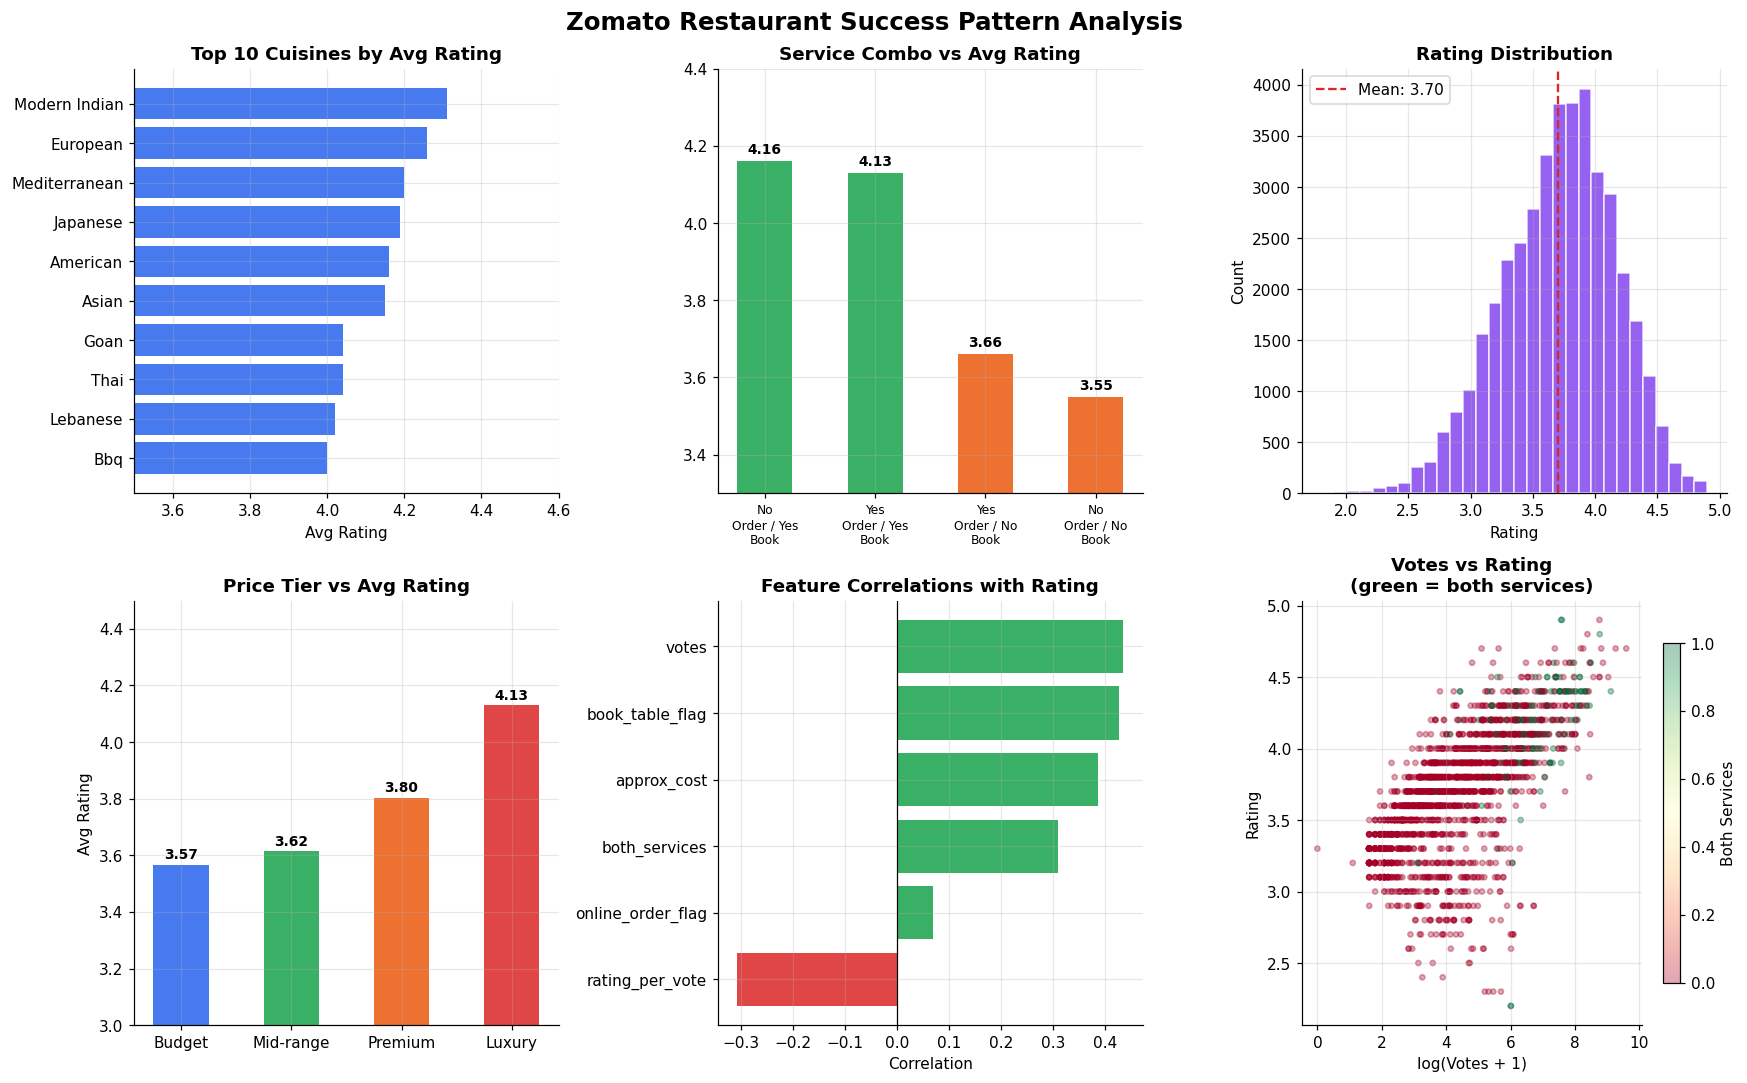

Chart saved ✅


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Zomato Restaurant Success Pattern Analysis", fontsize=16, fontweight='bold')

BLUE, GREEN, ORANGE, RED, PURPLE = '#2563EB', '#16A34A', '#EA580C', '#DC2626', '#7C3AED'

# 1 — Top cuisines by avg rating
ax = axes[0, 0]
tc = cuisine_df.nlargest(10, 'avg_rating')
ax.barh(tc['primary_cuisine'], tc['avg_rating'], color=BLUE, alpha=0.85)
ax.set_xlim(3.5, 4.6)
ax.set_title("Top 10 Cuisines by Avg Rating", fontweight='bold')
ax.set_xlabel("Avg Rating")
ax.invert_yaxis()

# 2 — Service combo vs avg rating
ax = axes[0, 1]
service_df['combo'] = service_df['online_order'] + '\nOrder / ' + service_df['book_table'] + '\nBook'
bar_colors = [GREEN if r >= 4.0 else BLUE if r >= 3.8 else ORANGE for r in service_df['avg_rating']]
ax.bar(range(len(service_df)), service_df['avg_rating'], color=bar_colors, alpha=0.85, width=0.5)
ax.set_xticks(range(len(service_df)))
ax.set_xticklabels(service_df['combo'], fontsize=8)
ax.set_ylim(3.3, 4.4)
ax.set_title("Service Combo vs Avg Rating", fontweight='bold')
for i, val in enumerate(service_df['avg_rating']):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# 3 — Rating distribution
ax = axes[0, 2]
ax.hist(df_clean['rate'], bins=30, color=PURPLE, alpha=0.8, edgecolor='white')
ax.axvline(df_clean['rate'].mean(), color=RED, linestyle='--', linewidth=1.5,
           label=f"Mean: {df_clean['rate'].mean():.2f}")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Rating Distribution", fontweight='bold')
ax.legend()

# 4 — Price tier vs avg rating
ax = axes[1, 0]
tier_stats = df_clean.groupby('price_tier', observed=True)['rate'].mean().reset_index()
tier_stats.columns = ['tier', 'avg_rating']
ax.bar(tier_stats['tier'].astype(str), tier_stats['avg_rating'],
       color=[BLUE, GREEN, ORANGE, RED][:len(tier_stats)], alpha=0.85, width=0.5)
ax.set_ylim(3.0, 4.5)
ax.set_title("Price Tier vs Avg Rating", fontweight='bold')
ax.set_ylabel("Avg Rating")
for i, val in enumerate(tier_stats['avg_rating']):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# 5 — Correlation chart
ax = axes[1, 1]
cs = pd.Series(corr_with_rating).sort_values()
colors = [GREEN if v > 0 else RED for v in cs]
ax.barh(cs.index, cs.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Correlations with Rating", fontweight='bold')
ax.set_xlabel("Correlation")

# 6 — Votes vs Rating scatter
ax = axes[1, 2]
sample = df_clean.sample(min(2000, len(df_clean)), random_state=42)
sc = ax.scatter(np.log1p(sample['votes']), sample['rate'],
                c=sample['both_services'], cmap='RdYlGn', alpha=0.35, s=12)
ax.set_xlabel("log(Votes + 1)")
ax.set_ylabel("Rating")
ax.set_title("Votes vs Rating\n(green = both services)", fontweight='bold')
plt.colorbar(sc, ax=ax, shrink=0.8, label="Both Services")

plt.tight_layout()
plt.savefig("zomato_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved ✅")


## Step 6 — Key Insights

In [11]:
both = df_clean[df_clean['both_services'] == 1]['rate'].mean()
none = df_clean[(df_clean['online_order_flag']==0) & (df_clean['book_table_flag']==0)]['rate'].mean()

print("=" * 55)
print("KEY INSIGHTS")
print("=" * 55)
print(f"  Both services avg rating  : {both:.2f} ★")
print(f"  No services avg rating    : {none:.2f} ★")
print(f"  Difference                : +{both - none:.2f} stars")
print()
print(f"  Top cuisine               : {cuisine_df.iloc[0]['primary_cuisine']} ({cuisine_df.iloc[0]['avg_rating']}★)")
print(f"  Strongest predictor       : book_table_flag")
print(f"  Total restaurants analysed: {df_clean.shape[0]:,}")


KEY INSIGHTS
  Both services avg rating  : 4.13 ★
  No services avg rating    : 3.55 ★
  Difference                : +0.58 stars

  Top cuisine               : Modern Indian (4.31★)
  Strongest predictor       : book_table_flag
  Total restaurants analysed: 41,418
